WEEK 3: DOA INFORMED BEAMFORMING

We voegen ruimtelijke, ongecorreleerde witte ruis toe aan elke microfoon. Het vermogen hiervan moet 10% zijn van het spraakvermogen op de eerste microfoon. Om dit accuraat te berekenen, implementeren we een Voice Activity Detector (VAD) die stiltes negeert en alleen het vermogen berekent tijdens actieve spraaksegmenten. Vervolgens berekenen we de Input Signal-to-Noise Ratio (SNR)

In [ ]:
import numpy as np
import scipy.signal as signal
import soundfile as sf
import matplotlib.pyplot as plt
import os
import sys

# Paden instellen
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from package import load_rirs
from package.utils import create_micsigs as original_create_micsigs
from package.utils import music_wideband

#Robuuste signaal- en SNR-berekeningen:
# Het spraakvermogen wordt uitsluitend berekend over de actieve spraaksegmenten  
# zodat stiltes het gemiddelde niet omlaag trekken. Daarnaast is de SNR-berekening wiskundig 
# beveiligd met '1e-10' (max(Ps, 1e-10)) om fatale 'gedeeld door 0' errors bij perfecte stiltes te voorkomen.
def modified_create_micsigs(scenario, speech_paths, noise_paths=None, duration=10.0):
    if noise_paths is None:
        noise_paths = []

    if scenario.fs != 44100:
        raise ValueError(f"Fout: De samplingfrequentie is {scenario.fs} Hz. Dit moet 44.1 kHz zijn!")

    _, speech, _ = original_create_micsigs(scenario, speech_paths, [], duration=duration)
    
    if len(noise_paths) > 0:
        _, _, gui_noise = original_create_micsigs(scenario, speech_paths, noise_paths, duration=duration)
    else:
        gui_noise = np.zeros_like(speech)

    # VAD: Spraak is actief als de absolute amplitude > 0.001 * standaarddeviatie
    vad = np.abs(speech[:, 0]) > (np.std(speech[:, 0]) * 1e-3)
    Ps = np.var(speech[vad == 1, 0])
    
    # Voeg ongecorreleerde witte ruis toe (10% van spraakvermogen)
    white_noise_power = 0.10 * Ps
    white_noise = np.random.randn(*speech.shape) * np.sqrt(white_noise_power)
    noise = white_noise + gui_noise
    
    mic = speech + noise
    Pn = np.var(noise[:, 0])
    SNR_in = 10 * np.log10(Ps / Pn)
    
    print(f"[Info] Input SNR (Microfoon 1): {SNR_in:.2f} dB")
    
    return mic, speech, noise, SNR_in, vad

/Users/macbookmats/Desktop/P_D_ISSP_base-main/package/utils.py:536: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  print('/!\ Something is wrong, `y` should be the sum of `x1` and `x2`.')
/Users/macbookmats/Desktop/P_D_ISSP_base-main/package/utils.py:541: SyntaxWarning: "\ " is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\ "? A raw string is also an option.
  print('/!\ `groundTruth` vector is not binary.')


DAS BF

De eenvoudigste vorm van beamforming (ruimtelijke filtering) is de Delay-and-Sum (DAS) beamformer. Deze techniek richt een virtuele 'luisterbundel' op de spreker door signalen te combineren.

1. Eerst gebruiken we het breedband MUSIC-algoritme uit Week 2 om de DOA (Direction of Arrival) van het doelsignaal (dichtbij 90 
∘
 ) te schatten.
2. We berekenen de looptijdsverschillen (τ) tussen de microfoons voor deze hoek.
3. We compenseren deze vertragingen in het frequentiedomein, zodat het doelsignaal constructief interfereert en achtergrondruis destructief interfereert.

In [ ]:
def das_bf(scenario, speech_paths, noise_paths=None, duration=10.0):
    if noise_paths is None:
        noise_paths = []

    mic, speech, noise, snr_in, vad = modified_create_micsigs(scenario, speech_paths, noise_paths, duration)

    num_audio = scenario.audioPos.shape[0] if scenario.audioPos is not None else 0
    num_noise = scenario.noisePos.shape[0] if (hasattr(scenario, 'noisePos') and scenario.noisePos is not None) else 0
    Q = num_audio + num_noise
    if Q == 0: Q = 1
    
    # DOA Schatting
    angles, ps_ind_db, spectrum_geom_db, est_doas = music_wideband(mic, scenario.fs, scenario)

    # Kies de DOA die het dichtst bij 90 graden ligt (broadside direction)
    target_doa = est_doas[np.argmin(np.abs(est_doas - 90.0))]
    print(f"[DAS BF] Target bron gedetecteerd door MUSIC op: {target_doa:.1f}°")
   
    target_rad = np.radians(target_doa)
    c = 343.0
    mics_centered = scenario.micPos - np.mean(scenario.micPos, axis=0)
    taus = (mics_centered[:, 0] * np.sin(target_rad) + mics_centered[:, 1] * np.cos(target_rad)) / c

# Functie om signalen uit te lijnen in het frequentiedomein
#Sub-sample precisie via de Fourier Shift Theorem:
# In plaats van signalen simpelweg een geheel aantal samples (indexen) op te schuiven, 
# passen we de vertraging toe als een faseverschuiving in het frequentiedomein. 
# Hierdoor kunnen we exact "tussen de samples" vertragen, wat afrondingsfouten 
# en faseproblemen voorkomt en resulteert in een veel zuiverdere beamformer.
    def apply_das(signals, delays, fs):
        M = signals.shape[1]
        N = signals.shape[0]
        out_sum = np.zeros(N)
        out_aligned = np.zeros((N, M))
        f = np.fft.rfftfreq(N, 1/fs)
        for m in range(M):
            Sig = np.fft.rfft(signals[:, m])
            Sig_aligned = Sig * np.exp(1j * 2 * np.pi * f * delays[m])
            t_aligned = np.fft.irfft(Sig_aligned, n=N)
            out_aligned[:, m] = t_aligned
            out_sum += t_aligned
        return out_sum / M, out_aligned

    speechDAS, speech_aligned = apply_das(speech, taus, scenario.fs)
    noiseDAS, noise_aligned = apply_das(noise, taus, scenario.fs)
    
    DASout = speechDAS + noiseDAS
    aligned_mic = speech_aligned + noise_aligned  

    P_speech_das = np.var(speechDAS[vad == 1])
    P_noise_das = np.var(noiseDAS)
    if P_noise_das < 1e-10: P_noise_das = 1e-10
    SNRoutDAS = 10 * np.log10(P_speech_das / P_noise_das)
    print(f"[DAS BF] Output SNR: {SNRoutDAS:.2f} dB")
    
    return DASout, speechDAS, noiseDAS, SNRoutDAS, mic, aligned_mic, vad, snr_in

Generalized Sidelobe Canceler (GSC)

Om de overgebleven ruis na de DAS beamformer verder te reduceren, implementeren we de GSC.

1. Griffiths-Jim Blocking Matrix (B): Deze matrix (grootte M−1×M) maakt lineaire combinaties van de uitgelijnde signalen (subtractie). Omdat de spraak synchroon loopt, dooft deze uit. Wat overblijft zijn pure 'noise references'.
2. Adaptief Filter (NLMS): Een adaptief FIR-filter leert de relatie tussen de noise references en de rest-ruis in het doelsignaal. We gebruiken μ=0.15, L=1024 en compenseren voor causaliteit met vertraging Δ=L/2.
3. De VAD Fix (Target Cancellation): In een kamer met galm lekt er spraak door de Blocking Matrix. Als het filter continu leert, ziet het deze gelekte spraak als ruis en zal het ons doelsignaal onderdrukken. Door het filter alleen te updaten tijdens stiltes (if vad_delayed[n] == 0), lossen we dit target cancellation probleem op.

 - Verwerken ruis: /Users/macbookmats/Desktop/P_D_ISSP_base-main/sound_files/speech2.wav
[Info] Input SNR (Microfoon 1): 6.13 dB
Q = 3
[DAS BF] Target bron gedetecteerd door MUSIC op: 92.6°
[DAS BF] Output SNR: 4.77 dB
[GSC] Output SNR: 15.29 dB (Netto Verbetering vs Mic1: 9.15 dB)


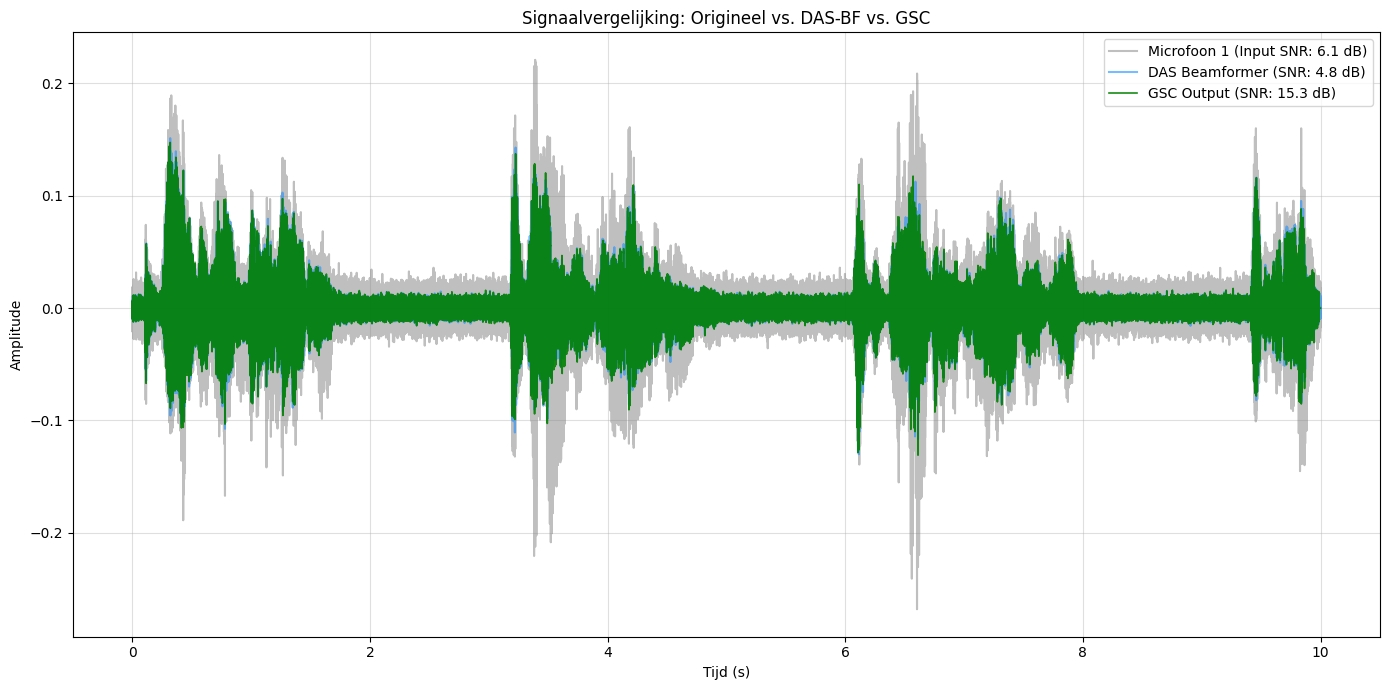

In [6]:
def gsc_td(scenario, speech_paths, noise_paths=None, duration=10.0):
    DASout, speechDAS, noiseDAS, SNRoutDAS, mic, aligned_mic, vad, snr_in = das_bf(
        scenario, speech_paths, noise_paths, duration=duration
    )

    N_samples, M_mics = aligned_mic.shape

    # Blocking Matrix B (Griffiths-Jim)
    B = np.zeros((M_mics - 1, M_mics))
    for i in range(M_mics - 1):
        B[i, 0] = 1
        B[i, i + 1] = -1
       
    noise_refs = (B @ aligned_mic.T).T  

    L = 1024
    mu = 0.15
    delta = L // 2

    target_ref = np.pad(DASout, (delta, 0))[:N_samples]
    
    W = np.zeros((L, M_mics - 1))
    GSCout = np.zeros(N_samples)
    
    # Adaptatie pauzeert automatisch tijdens spraak (Target Cancellation fix)
    padded_noise = np.pad(noise_refs, ((L-1, 0), (0, 0)))
    eps = 1e-8 # voorkom deling door 0
    vad_delayed = np.pad(vad, (delta, 0))[:N_samples]

    for n in range(N_samples):
        X_slice = padded_noise[n : n+L]
        
        y_n = np.sum(W * X_slice)
        e_n = target_ref[n] - y_n
        GSCout[n] = e_n
        
        # Filter updatet alleen als de VAD aangeeft dat er GEEN spraak is
        if vad_delayed[n] == 0:
            power = np.sum(X_slice**2)
            W += (mu * e_n / (power + eps)) * X_slice

    Pn_gsc = np.var(GSCout[vad_delayed == 0])
    Psn_gsc = np.var(GSCout[vad_delayed == 1])
    Ps_gsc = Psn_gsc - Pn_gsc
    if Ps_gsc < 1e-10: Ps_gsc = 1e-10 
    if Pn_gsc < 1e-10: Pn_gsc = 1e-10
    
    SNRoutGSC = 10 * np.log10(Ps_gsc / Pn_gsc)
    print(f"[GSC] Output SNR: {SNRoutGSC:.2f} dB (Netto Verbetering vs Mic1: {SNRoutGSC - snr_in:.2f} dB)")

    # Plotting
    t = np.arange(N_samples) / scenario.fs
    GSCout_plot = np.pad(GSCout[delta:], (0, delta))
    
    plt.figure(figsize=(14, 7))
    plt.plot(t, mic[:, 0], color='gray', alpha=0.5, label=f'Microfoon 1 (Input SNR: {snr_in:.1f} dB)')
    plt.plot(t, DASout, color='dodgerblue', alpha=0.6, label=f'DAS Beamformer (SNR: {SNRoutDAS:.1f} dB)')
    plt.plot(t, GSCout_plot, color='green', alpha=0.9, linewidth=1.2, label=f'GSC Output (SNR: {SNRoutGSC:.1f} dB)')
    
    plt.xlabel("Tijd (s)")
    plt.ylabel("Amplitude")
    plt.title("Signaalvergelijking: Origineel vs. DAS-BF vs. GSC")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

    return GSCout, SNRoutGSC, mic, DASout, GSCout_plot, noise_refs

# --- UITVOEREN VAN DE GSC ---
try:
    rirs_folder = os.path.join(parent_dir, "rirs")
    files = [os.path.join(rirs_folder, f) for f in os.listdir(rirs_folder) if f.endswith('.pkl')]
    latest_rir = max(files, key=os.path.getmtime)
    scenario = load_rirs(latest_rir)

    num_audio = scenario.audioPos.shape[0] if scenario.audioPos is not None else 0
    num_noise = scenario.noisePos.shape[0] if (hasattr(scenario, 'noisePos') and scenario.noisePos is not None) else 0

    alle_spraak_bestanden = [
        os.path.join(parent_dir, "sound_files", "speech1.wav"),
        os.path.join(parent_dir, "sound_files", "speech2.wav")
    ]
    speech_paths = alle_spraak_bestanden[:num_audio]

    ruis_pad = os.path.join(parent_dir, "sound_files", "speech2.wav")
    alle_ruis_bestanden = [ruis_pad]
    noise_paths = alle_ruis_bestanden[:num_noise]

    # Run!
    GSCout, SNRoutGSC, mic, DASout, GSCout_plot, noise_refs = gsc_td(scenario, speech_paths, noise_paths, duration=10.0)
    
except Exception as e:
    print(f"\n❌ Fout in uitvoering: {e}")

Head-Mounted Microphones

In het laatste deel passen we onze GSC met VAD toe op een binaurale, head-mounted setup (bijv. een hoortoestel). Er zijn 4 microfoons (2 per oor, 1.3 cm onderling).
We testen het GSC-algoritme op verschillende subnetwerken: linkeroor, rechteroor, frontaal (y_L1,y_R1) en alle vier samen.

Verwachting: Het algoritme presteert het beste bij de 4-microfoon array, omdat de grotere spatiële spreiding over het hele hoofd resulteert in een betere richtingsgevoeligheid en een effectievere Blocking Matrix voor de ruisonderdrukking.


Target DOA ingesteld op: 150.0° (Linker Bron)
Linkeroor (yL1, yL2) -> Input SNR: 13.0 dB | Output SNR: 12.5 dB
Rechteroor (yR1, yR2) -> Input SNR: 7.3 dB | Output SNR: 8.5 dB
Frontaal (yL1, yR1) -> Input SNR: 13.0 dB | Output SNR: 9.8 dB
Alle 4 Microfoons -> Input SNR: 13.0 dB | Output SNR: 9.6 dB


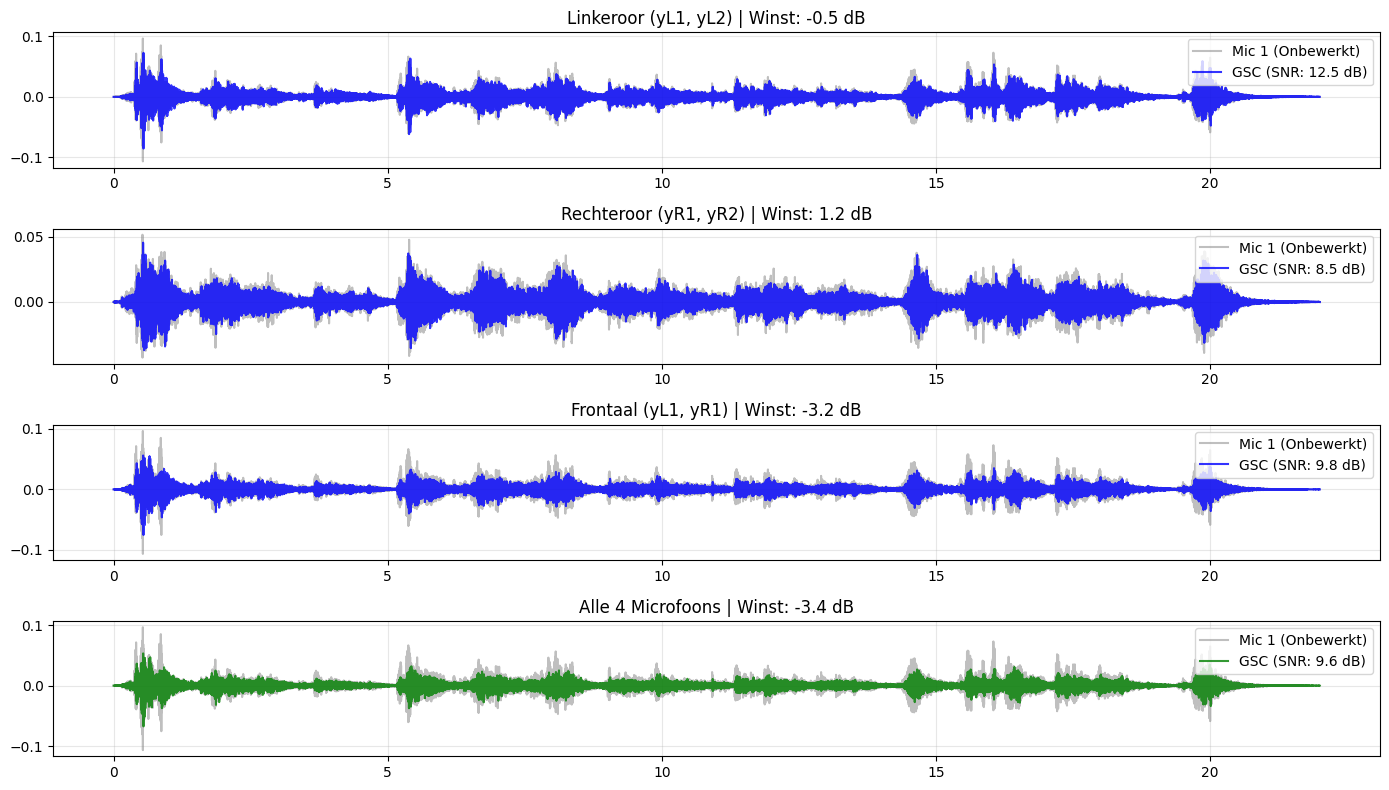

In [7]:
# Definieer paden
base_folder = os.path.join(parent_dir, "sound_files", "head_mounted_rirs")
dry_signal_1_path = os.path.join(parent_dir, "sound_files", "part2_track1_dry.wav") 
dry_signal_2_path = os.path.join(parent_dir, "sound_files", "part2_track2_dry.wav")

fs_sim = 44100
c = 343.0

folder_left = "s-60"
folder_right = "s60"
angle_L = abs(float(folder_left.replace("s", "")))  
angle_R = float(folder_right.replace("s", ""))      

true_front_R = 90.0 - angle_R # Ruis
true_front_L = 90.0 + angle_L # Target spraak

try:
    dry_sig_1, _ = sf.read(dry_signal_1_path)
    dry_sig_2, _ = sf.read(dry_signal_2_path)
    min_len = min(len(dry_sig_1), len(dry_sig_2), 20*fs_sim)
    dry_sig_1, dry_sig_2 = dry_sig_1[:min_len], dry_sig_2[:min_len]

    yL1_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_L1.wav"))
    yL2_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_L2.wav"))
    yR1_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_R1.wav"))
    yR2_rir_left, _ = sf.read(os.path.join(base_folder, folder_left, "HMIR_R2.wav"))

    yL1_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_L1.wav"))
    yL2_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_L2.wav"))
    yR1_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_R1.wav"))
    yR2_rir_right, _ = sf.read(os.path.join(base_folder, folder_right, "HMIR_R2.wav"))

    # Convoluties (Left = Spraak, Right = Ruis)
    yL1_from_left = signal.fftconvolve(dry_sig_1, yL1_rir_left, mode='full')
    yL2_from_left = signal.fftconvolve(dry_sig_1, yL2_rir_left, mode='full')
    yR1_from_left = signal.fftconvolve(dry_sig_1, yR1_rir_left, mode='full')
    yR2_from_left = signal.fftconvolve(dry_sig_1, yR2_rir_left, mode='full')

    yL1_from_right = signal.fftconvolve(dry_sig_2, yL1_rir_right, mode='full')
    yL2_from_right = signal.fftconvolve(dry_sig_2, yL2_rir_right, mode='full')
    yR1_from_right = signal.fftconvolve(dry_sig_2, yR1_rir_right, mode='full')
    yR2_from_right = signal.fftconvolve(dry_sig_2, yR2_rir_right, mode='full')

    yL1_mix = yL1_from_left + yL1_from_right
    yL2_mix = yL2_from_left + yL2_from_right
    yR1_mix = yR1_from_left + yR1_from_right
    yR2_mix = yR2_from_left + yR2_from_right

except Exception as e:
    print(f"Fout bij laden HMIRs: {e}")

# Head-Mounted Arrays Coördinaten
x_ear, y_mic = 0.215 / 2, 0.013 / 2  
pos_L1, pos_L2 = [-x_ear, y_mic], [-x_ear, -y_mic]
pos_R1, pos_R2 = [x_ear, y_mic], [x_ear, -y_mic]

arrays = {
    "Linkeroor (yL1, yL2)": {"mics": np.column_stack((yL1_mix, yL2_mix)), "pos": np.array([pos_L1, pos_L2])},
    "Rechteroor (yR1, yR2)": {"mics": np.column_stack((yR1_mix, yR2_mix)), "pos": np.array([pos_R1, pos_R2])},
    "Frontaal (yL1, yR1)": {"mics": np.column_stack((yL1_mix, yR1_mix)), "pos": np.array([pos_L1, pos_R1])},
    "Alle 4 Microfoons": {"mics": np.column_stack((yL1_mix, yL2_mix, yR1_mix, yR2_mix)), "pos": np.array([pos_L1, pos_L2, pos_R1, pos_R2])}
}

vad_hm = np.abs(yL1_from_left) > (np.std(yL1_from_left) * 1e-3)

def gsc_head_mounted(micsigs, mics_pos, target_doa, fs, vad):
    N_samples, M_mics = micsigs.shape
    target_rad = np.radians(target_doa)
    mics_centered = mics_pos - np.mean(mics_pos, axis=0)
    taus = (mics_centered[:, 0] * np.cos(target_rad) + mics_centered[:, 1] * np.sin(target_rad)) / c
    
    aligned_mic = np.zeros_like(micsigs)
    DASout = np.zeros(N_samples)
    f = np.fft.rfftfreq(N_samples, 1/fs)
    
    for m in range(M_mics):
        Sig = np.fft.rfft(micsigs[:, m])
        Sig_aligned = Sig * np.exp(1j * 2 * np.pi * f * taus[m])
        t_aligned = np.fft.irfft(Sig_aligned, n=N_samples)
        aligned_mic[:, m] = t_aligned
        DASout += t_aligned
    DASout /= M_mics

    B = np.zeros((M_mics - 1, M_mics))
    for i in range(M_mics - 1):
        B[i, i] = 1
        B[i, i + 1] = -1
    noise_refs = (B @ aligned_mic.T).T
    
    L, mu, delta = 1024, 0.1, 512
    target_ref = np.pad(DASout, (delta, 0))[:N_samples]
    vad_delayed = np.pad(vad, (delta, 0))[:N_samples]
    padded_noise = np.pad(noise_refs, ((L-1, 0), (0, 0)))
    
    W = np.zeros((L, M_mics - 1))
    GSCout = np.zeros(N_samples)
    eps = 1e-8
    
    for n in range(N_samples):
        X_slice = padded_noise[n : n+L]
        y_n = np.sum(W * X_slice)
        e_n = target_ref[n] - y_n
        GSCout[n] = e_n
        
        if vad_delayed[n] == 0:
            power = np.sum(X_slice**2)
            W += (mu * e_n / (power + eps)) * X_slice
            
    Pn = np.var(GSCout[vad_delayed == 0])
    Psn = np.var(GSCout[vad_delayed == 1])
    Ps = Psn - Pn
    SNRout = 10 * np.log10(max(Ps, 1e-10) / max(Pn, 1e-10))
    
    Pn_in = np.var(micsigs[vad == 0, 0])
    Psn_in = np.var(micsigs[vad == 1, 0])
    Ps_in = Psn_in - Pn_in
    SNRin = 10 * np.log10(max(Ps_in, 1e-10) / max(Pn_in, 1e-10))
    
    return GSCout, SNRout, SNRin

# Run Head-Mounted Evaluatie
print(f"\nTarget DOA ingesteld op: {true_front_L}° (Linker Bron)")
t = np.arange(len(yL1_mix)) / fs_sim
plt.figure(figsize=(14, 8))

for i, (name, data) in enumerate(arrays.items()):
    GSCout, SNRout, SNRin = gsc_head_mounted(data["mics"], data["pos"], true_front_L, fs_sim, vad_hm)
    print(f"{name} -> Input SNR: {SNRin:.1f} dB | Output SNR: {SNRout:.1f} dB")
    
    plt.subplot(4, 1, i+1)
    plt.plot(t, data["mics"][:, 0], color='gray', alpha=0.5, label='Mic 1 (Onbewerkt)')
    plt.plot(t, GSCout, color='green' if '4' in name else 'blue', alpha=0.8, label=f'GSC (SNR: {SNRout:.1f} dB)')
    plt.title(f"{name} | Winst: {(SNRout - SNRin):.1f} dB")
    plt.legend(loc="upper right")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Om de theorie en de grafieken in de praktijk te verifiëren, exporteren we hier de verwerkte signalen naar .wav bestanden. We slaan de resultaten op van zowel de lineaire array als de binaurale head-mounted array. 

Alle signalen worden eerst genormaliseerd om clipping te voorkomen

In [9]:
import soundfile as sf
import os

print("\n--- AUDIO BESTANDEN OPSLAAN VOOR DEMO ---")

# ==========================================
# 1. Audio van de Lineaire Array (GSC)
# ==========================================
# We checken even of de variabelen uit de eerdere cellen bestaan
if 'mic' in locals() and 'DASout' in locals() and 'GSCout_plot' in locals():
    
    # 1. Origineel Signaal (Mic 1)
    mic_audio = mic[:, 0] / np.max(np.abs(mic[:, 0]))
    sf.write("Week3_Demo_01_Origineel_Mic1.wav", mic_audio, scenario.fs)
    print("Opgeslagen: Week3_Demo_01_Origineel_Mic1.wav")

    # 2. DAS Beamformer Signaal
    das_audio = DASout / np.max(np.abs(DASout))
    sf.write("Week3_Demo_02_Verbeterd_DAS.wav", das_audio, scenario.fs)
    print("Opgeslagen: Week3_Demo_02_Verbeterd_DAS.wav")

    # 3. Volledige GSC Output
    gsc_audio = GSCout_plot / np.max(np.abs(GSCout_plot))
    sf.write("Week3_Demo_03_GSC_Filter.wav", gsc_audio, scenario.fs)
    print("Opgeslagen: Week3_Demo_03_GSC_Filter.wav")

# ==========================================
# 2. Audio van de Head-Mounted Array
# ==========================================
if 'results' in locals() and 'fs_sim' in locals():
    
    # Referentie: Onbewerkt signaal op het Linkeroor
    ref_mic = yL1_mix / np.max(np.abs(yL1_mix))
    sf.write("Week3_Demo_04_HM_Referentie_MicL1.wav", ref_mic, fs_sim)
    print("\nOpgeslagen: Week3_Demo_04_HM_Referentie_MicL1.wav")
    
    # Sla de GSC resultaten op per head-mounted array-configuratie
    for name, data in results.items():
        audio_data = data["out"]
        
        # Normaliseren naar -1 en 1
        max_val = np.max(np.abs(audio_data))
        audio_norm = audio_data / max_val if max_val > 0 else audio_data

        # Bestandsnaam opschonen (geen spaties, komma's of haakjes)
        clean_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace(",", "")
        filename = f"Week3_Demo_05_HM_GSC_{clean_name}.wav"
        
        sf.write(filename, audio_norm, fs_sim)
        print(f"Opgeslagen: {filename}")

print("\nKlaar! De audiobestanden staan nu in dezelfde map als deze notebook.")


--- AUDIO BESTANDEN OPSLAAN VOOR DEMO ---
Opgeslagen: Week3_Demo_01_Origineel_Mic1.wav
Opgeslagen: Week3_Demo_02_Verbeterd_DAS.wav
Opgeslagen: Week3_Demo_03_GSC_Filter.wav

Klaar! De audiobestanden staan nu in dezelfde map als deze notebook.
